In [1]:
import kagglehub
import shutil
import os

# Download latest version
path = kagglehub.competition_download('titanic')

# Destino
destino = r'C:\Users\dyego\Documents\Projetos\titanic\data'

# Cria a pasta se não existir
os.makedirs(destino, exist_ok=True)

#move os arquivos para o destino
for arquivo in os.listdir(path):
    origem = os.path.join(path, arquivo)
    destino_arquivo = os.path.join(destino, arquivo)
    shutil.move(origem, destino_arquivo)
print(f'Arquivos movidos para {destino}')

c:\virtualenvs\ML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Arquivos movidos para C:\Users\dyego\Documents\Projetos\titanic\data


In [2]:
import pandas as pd
import numpy as np

In [3]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
vazios = train.isnull().isna().sum()
duplicados = train.duplicated().sum()
print(vazios)
print(duplicados)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64
0


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [7]:
modelo = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)

In [8]:
from src.utils import transformar_sexo

In [9]:
variaveis = ['Sex_binary', 'Age']
train['Sex_binary'] = train['Age'].map(transformar_sexo)
test['Sex_binary'] = test['Age'].map(transformar_sexo)


In [10]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_binary
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [11]:


train['Sex_binary'] = train['Age'].map(transformar_sexo)
test['Sex_binary'] = test['Age'].map(transformar_sexo)

X = train[variaveis].fillna(-1)
y = train["Survived"]

In [12]:
print(X.head())
print(y.head())

   Sex_binary   Age
0           0  22.0
1           0  38.0
2           0  26.0
3           0  35.0
4           0  35.0
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [13]:
modelo.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
X_prev = test[variaveis]

In [15]:
X_prev.head()

,Sex_binary,Age
0,0,34.5
1,0,47.0
2,0,62.0
3,0,27.0
4,0,22.0


In [16]:
p = modelo.predict(X_prev)
p

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,

In [17]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_binary
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0


In [18]:
sub = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': p})

In [19]:
sub.to_csv('../submission/submission1.csv', header=True, index=False)
sub.head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0
5,897,1
6,898,0
7,899,0
8,900,0
9,901,0


## Modelo 2
* implementando from sklearn.model_selection import train_test_split

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=0)

In [22]:
modelo = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
modelo.fit(X_treino, y_treino)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
p = modelo.predict(X_teste)

In [24]:
# Validação do modelo
print(y_teste == p)
print(np.mean(y_teste == p))

495     True
648     True
278     True
31     False
255    False
       ...  
780     True
837     True
215    False
833     True
372     True
Name: Survived, Length: 179, dtype: bool
0.6368715083798883


# validação cruzada

In [25]:
from sklearn.model_selection import KFold, RepeatedKFold

In [26]:
?RepeatedKFold

Init signature: RepeatedKFold(*, n_splits=5, n_repeats=10, random_state=None)
Docstring:     
Repeated K-Fold cross validator.

Repeats K-Fold `n_repeats` times with different randomization in each repetition.

Read more in the :ref:`User Guide <repeated_k_fold>`.

Parameters
----------
n_splits : int, default=5
    Number of folds. Must be at least 2.

n_repeats : int, default=10
    Number of times cross-validator needs to be repeated.

random_state : int, RandomState instance or None, default=None
    Controls the randomness of each repeated cross-validation instance.
    Pass an int for reproducible output across multiple function calls.
    See :term:`Glossary <random_state>`.

Examples
--------
>>> import numpy as np
>>> from sklearn.model_selection import RepeatedKFold
>>> X = np.array([[1, 2], [3, 4], [1, 2], [3, 4]])
>>> y = np.array([0, 0, 1, 1])
>>> rkf = RepeatedKFold(n_splits=2, n_repeats=2, random_state=2652124)
>>> rkf.get_n_splits(X, y)
4
>>> print(rkf)
RepeatedKFold(n_

In [27]:
resultados = []
for rep in range(10):
    print("Repetição:", rep)
    kf = KFold(2, shuffle=True, random_state=rep) 

    

    for Linha_treino, Linha_valid in kf.split(X):
        print("Treino:", X.iloc[Linha_treino].shape[0])
        print("Teste:", X.iloc[Linha_valid].shape[0])

        X_treino, X_teste = X.iloc[Linha_treino], X.iloc[Linha_valid]
        y_treino, y_teste = y.iloc[Linha_treino], y.iloc[Linha_valid]
        
        modelo = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
        modelo.fit(X_treino, y_treino)

        p = modelo.predict(X_teste)
        
        acc = np.mean(y_teste == p)
        resultados.append(acc) 
        print("Acurácia:", acc)
        print()
    
    # print(X_treino.head())
    # print()

Repetição: 0
Treino: 445
Teste: 446
Acurácia: 0.6143497757847534

Treino: 446
Teste: 445
Acurácia: 0.604494382022472

Repetição: 1
Treino: 445
Teste: 446
Acurácia: 0.6031390134529148

Treino: 446
Teste: 445
Acurácia: 0.5797752808988764

Repetição: 2
Treino: 445
Teste: 446
Acurácia: 0.6053811659192825

Treino: 446
Teste: 445
Acurácia: 0.6202247191011236

Repetição: 3
Treino: 445
Teste: 446
Acurácia: 0.6121076233183856

Treino: 446
Teste: 445
Acurácia: 0.6089887640449438

Repetição: 4
Treino: 445
Teste: 446
Acurácia: 0.5672645739910314

Treino: 446
Teste: 445
Acurácia: 0.5573033707865168

Repetição: 5
Treino: 445
Teste: 446
Acurácia: 0.6076233183856502

Treino: 446
Teste: 445
Acurácia: 0.6067415730337079

Repetição: 6
Treino: 445
Teste: 446
Acurácia: 0.5919282511210763

Treino: 446
Teste: 445
Acurácia: 0.6157303370786517

Repetição: 7
Treino: 445
Teste: 446
Acurácia: 0.5538116591928252

Treino: 446
Teste: 445
Acurácia: 0.5820224719101124

Repetição: 8
Treino: 445
Teste: 446
Acurácia: 0.5

In [28]:
variaveis = ['Sex_binary', 'Age', 'SibSp', 'Pclass', 'Parch', 'Fare']

In [29]:
resultados = []
kf = RepeatedKFold(n_splits=2, n_repeats=10, random_state=0)
for Linha_treino, Linha_valid in kf.split(X):
    print("Treino:", X.iloc[Linha_treino].shape[0])
    print("Teste:", X.iloc[Linha_valid].shape[0])

    X_treino, X_teste = X.iloc[Linha_treino], X.iloc[Linha_valid]
    y_treino, y_teste = y.iloc[Linha_treino], y.iloc[Linha_valid]
    
    modelo = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
    modelo.fit(X_treino, y_treino)

    p = modelo.predict(X_teste)
    
    acc = np.mean(y_teste == p)
    resultados.append(acc) 
    print("Acurácia:", acc)
    print()


Treino: 445
Teste: 446
Acurácia: 0.6143497757847534

Treino: 446
Teste: 445
Acurácia: 0.604494382022472

Treino: 445
Teste: 446
Acurácia: 0.6031390134529148

Treino: 446
Teste: 445
Acurácia: 0.5932584269662922

Treino: 445
Teste: 446
Acurácia: 0.5874439461883408

Treino: 446
Teste: 445
Acurácia: 0.5865168539325842

Treino: 445
Teste: 446
Acurácia: 0.5650224215246636

Treino: 446
Teste: 445
Acurácia: 0.6022471910112359

Treino: 445
Teste: 446
Acurácia: 0.5807174887892377

Treino: 446
Teste: 445
Acurácia: 0.597752808988764

Treino: 445
Teste: 446
Acurácia: 0.5807174887892377

Treino: 446
Teste: 445
Acurácia: 0.604494382022472

Treino: 445
Teste: 446
Acurácia: 0.5964125560538116

Treino: 446
Teste: 445
Acurácia: 0.5707865168539326

Treino: 445
Teste: 446
Acurácia: 0.5762331838565022

Treino: 446
Teste: 445
Acurácia: 0.6

Treino: 445
Teste: 446
Acurácia: 0.5964125560538116

Treino: 446
Teste: 445
Acurácia: 0.6

Treino: 445
Teste: 446
Acurácia: 0.6188340807174888

Treino: 446
Teste: 445
Acu

In [30]:
%matplotlib inline
%pylab


Using matplotlib backend: inline
%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


c:\virtualenvs\ML\Lib\site-packages\IPython\core\magics\pylab.py:166: UserWarning: pylab import has clobbered these variables: ['test']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [31]:
np.mean(resultados)

np.float64(0.5940540132009875)

(array([1., 1., 3., 1., 1., 3., 5., 3., 0., 2.]),
 array([0.56502242, 0.57040359, 0.57578475, 0.58116592, 0.58654709,
        0.59192825, 0.59730942, 0.60269058, 0.60807175, 0.61345291,
        0.61883408]),
 <BarContainer object of 10 artists>)

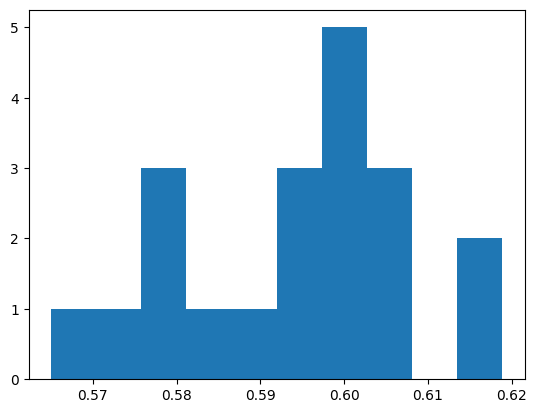

In [32]:
pylab.hist(resultados)

In [33]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

variaveis = ['Sex_binary', 'Age', 'Pclass', 'SibSp', 'Parch', 'Fare']

train['Sex_binary'] = train['Age'].map(transformar_sexo)
test['Sex_binary'] = test['Age'].map(transformar_sexo)

X = train[variaveis].fillna(-1)
y = train["Survived"]

In [34]:
test[variaveis].head()

,Sex_binary,Age,Pclass,SibSp,Parch,Fare
0,0,34.5,3,0,0,7.8292
1,0,47.0,3,1,0,7.0000
2,0,62.0,2,0,0,9.6875
3,0,27.0,3,0,0,8.6625
4,0,22.0,3,1,1,12.2875


In [35]:
modelo = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
modelo.fit(X, y)

p = modelo.predict(test[variaveis].fillna(-1))

In [36]:
p

array([0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

* Submissão

In [39]:
from src.kaggle import submeter_resultados

In [44]:
submeter_resultados(test, p, 'RandomForest')

Arquivo de submissão salvo em: ../submission/RandomForest.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,1
3,895,1
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
